In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs  # For geographic projections
import xarray as xr
import numpy as np
import cartopy.feature as cfeature  # For geographic features
from cartopy.util import add_cyclic_point  # For handling cyclic longitude points
from get_lat_lon import get_lat_lon  # Custom module for latitude/longitude data
from matplotlib.colors import CenteredNorm, TwoSlopeNorm, Normalize

# Load latitude and longitude data from numpy files
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")

# Load input data arrays
x = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y2 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")
y = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]  # Extract last dimension

# Identify and remove NaN values from the data
nanindex = np.where(np.isnan(y[:,205]))
x = np.delete(x, nanindex, axis=0)
y = np.delete(y, nanindex, axis=0)
y2 = np.delete(y2, nanindex, axis=0)
lats = np.delete(lats, nanindex, axis=0)
lons = np.delete(lons, nanindex, axis=0)

# Load model evaluation results from multiple runs
s0 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/566/eg_30_eval.npy")
s1 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567/eg_30_eval.npy")
s2 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/568/eg_30_eval.npy")
s3 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/569/eg_30_eval-1.npy")

# Create a 1x4 subplot figure with PlateCarree projection for geographic mapping
fig, axis = plt.subplots(1, 4, subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(10,3))

# Store all evaluation results in a list
slist = [s0, s1, s2, s3]
# Set color normalization range for consistent coloring across plots
norm = Normalize(-0.0001, 0.0001)


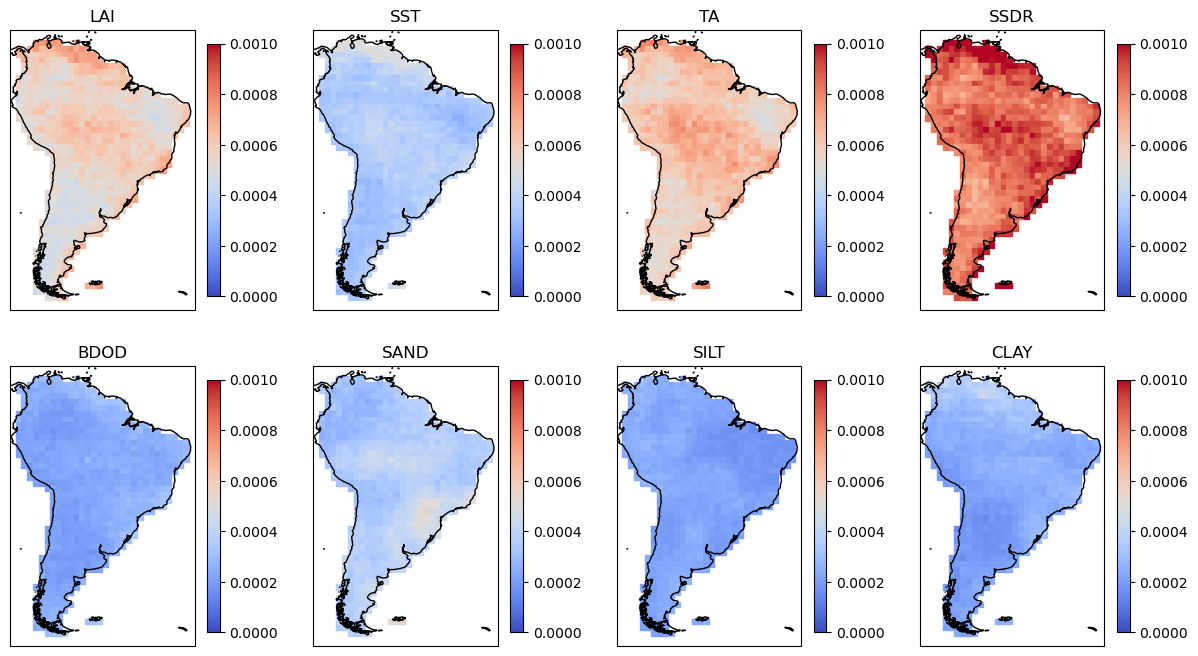

In [6]:
# Import CenteredNorm for color normalization
from matplotlib.colors import CenteredNorm

# Create a 2x4 grid of subplots with geographic projection
fig, axis = plt.subplots(2, 4, subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(15,8))

# List of model evaluation results and variable names
slist = [s0, s1, s2, s3]
varlist = ["LAI", "SST", "TA", "SSDR", "BDOD", "SAND", "SILT", "CLAY"]

# Loop through each subplot (axis) and corresponding variable
for i, ax in enumerate(axis.flat):
    # Add coastlines to the geographic map
    ax.coastlines()  # cartopy function
    
    # Set color normalization range for consistent coloring
    norm = Normalize(0, 0.001)
    
    # Set title for each subplot with variable name
    ax.set_title(varlist[i])
    
    # Create a 5D array to store data from all four model runs for current variable
    xais_np_m = np.full((733, 4, 216, 21, 21), np.nan)
    
    # Populate the array with data from each model run
    for k in range(4):
        xais_np_m[:, k, :, :, :] = slist[k][:, i, :, :, :]
    
    # Calculate standard deviation across the 4 model runs (axis=1)
    std_np_m = np.std(xais_np_m, axis=1)
    
    # Compute mean standard deviation across spatial dimensions (3D to 1D reduction)
    std_mean_m = np.nanmean(np.nanmean(np.nanmean(std_np_m, axis=-1), axis=-1), axis=-1)
    
    # Create scatter plot showing geographic distribution of standard deviation
    sc = ax.scatter(lons[:], lats[:], s=15, c=std_mean_m, 
                   cmap='coolwarm', norm=norm, marker="s")
    
    # Add colorbar to each subplot for value interpretation
    fig.colorbar(sc, ax=ax, fraction=0.05)